In [1]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import os
import pandas as pd
import pickle
from HierarchBayesParcel.util import indicator
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
from IndividualParcellation.evaluate import calc_test_dcbc
from DCBC.utilities import compute_dist
import Functional_Fusion.atlas_map as am

In [2]:
a,_= am.get_atlas(atlas_str='MNISymC2')
dist = compute_dist(a.world.T, resolution=1)


# MDTB Vs

In [3]:
# mdtb vs based on HBP
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models'
if not os.path.exists(model_dir):
    model_dir = '/cifs/diedrichsen/data/Cerebellum/ProbabilisticParcellationModel/Models'
    
model_name = f'/Models_03/NettekovenSym32_space-MNISymC2'
fname = model_dir + model_name
with open(fname + '.pickle', 'rb') as file:
        full_model = pickle.load(file)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb = mdtb_1_Vs.detach().numpy()
GL_mdtb = VL_mdtb @ VL_mdtb.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

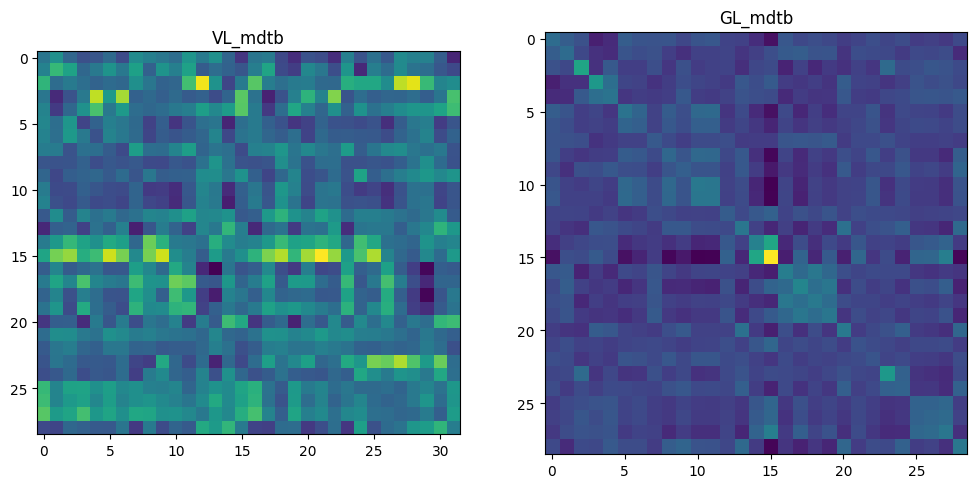

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_mdtb)
ax[0].set_title('VL_mdtb')

ax[1].imshow(GL_mdtb)
ax[1].set_title('GL_mdtb')

plt.show()

In [5]:
cond_vec = np.tile(np.arange(1, 17 + 1), 1)
part_vec = np.repeat(np.arange(1, 1 + 1), 17)

In [6]:
def HBP_u(train_data,cond_vec,part_vec,full_model):
    model = full_model 
    sym_type = 'sym'
    ar_model = model.arrange
    ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())
    x_matrix = indicator(cond_vec)
    
    
    em_model = em.MixVMF(K=32, P=18290, X=x_matrix, part_vec=part_vec,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([train_data])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    

    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation

    return U_data

In [7]:
def evaluate_cos(D,ytrain,Vs,ytest,vtest):
    for i, row in D.iterrows():
        print(i)
        task_subset_indices = row['combination']
        V_subset = Vs[task_subset_indices, :]
        
        # Subtract mean across rows
        V_subset = V_subset - np.mean(V_subset, axis=0)
        
        # Generate the data Y from U_true and V_subset
        y_subset = ytrain[:,task_subset_indices, :]

        # Estimate U_hat using OLS
        U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        U_hat_NNLS = sim.estimate_Us_NNLS(y_subset, V_subset)    

        # make into tensores
        ytest = pt.tensor(ytest,dtype=pt.float32)
        vtest = pt.tensor(vtest,dtype=pt.float32)
        U_hat_ols = pt.tensor(U_hat_ols,dtype=pt.float32)
        U_hat_NNLS = pt.tensor(U_hat_NNLS,dtype=pt.float32)
        # U_hat_HBP = HBP_u(y_subset,cond_vec,part_vec,full_model)
        

        cos_ols = ev.coserr(ytest,vtest,U_hat_ols).mean().numpy()
        cos_NNLS = ev.coserr(ytest,vtest,U_hat_NNLS).mean().numpy()
        # cos_HBP = ev.coserr(ytest,vtest,U_hat_HBP).mean().numpy()

        # Pindiv = pt.argmax(U_hat_HBP, dim=1) + 1
        # dcbc_indiv = calc_test_dcbc(Pindiv, ytest, dist)

        D.at[i, 'cos_ols'] = cos_ols
        D.at[i, 'cos_NNLS'] = cos_NNLS
        # D.at[i, 'cos_HBP'] = cos_HBP
        # D.at[i, 'dcbc_indiv'] = dcbc_indiv


    return D

In [9]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')
data_mdtb_s1_All,info_mdtb_1_All  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s1',type='CondAll')
data_mdtb_s1_All[np.isnan(data_mdtb_s1_All)] = 0

In [10]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')
data_mdtb_s2_All,info_mdtb_2_All  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s2',type='CondAll')
data_mdtb_s2_All[np.isnan(data_mdtb_s2_All)] = 0

In [11]:
D_mdtb = ut.build_combinations(GL_mdtb, strategy='random',n_iter=400,n_tasks=17,seed=5)
A_mdtb = D_mdtb[D_mdtb['offset'] == 0.001]
A_mdtb = evaluate_cos(A_mdtb, data_mdtb_s1_All,VL_mdtb, data_mdtb_s2_All, VL_mdtb_2)



1


C:\Users\barafat\AppData\Local\Temp\ipykernel_2076\358343638.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  D.at[i, 'cos_ols'] = cos_ols
C:\Users\barafat\AppData\Local\Temp\ipykernel_2076\358343638.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  D.at[i, 'cos_NNLS'] = cos_NNLS


4


C:\Users\barafat\AppData\Local\Temp\ipykernel_2076\358343638.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest,dtype=pt.float32)
C:\Users\barafat\AppData\Local\Temp\ipykernel_2076\358343638.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest,dtype=pt.float32)


7
10
13
16
19
22
25
28
31
34
37
40
43
46
49
52
55
58
61
64
67
70
73
76
79
82
85
88
91
94
97
100
103
106
109
112
115
118
121
124
127
130
133
136
139
142
145
148
151
154
157
160
163
166
169
172
175
178
181
184
187
190
193
196
199
202
205
208
211
214
217
220
223
226
229
232
235
238
241
244
247
250
253
256
259
262
265
268
271
274
277
280
283
286
289
292
295
298
301
304
307
310
313
316
319
322
325
328
331
334
337
340
343
346
349
352
355
358
361
364
367
370
373
376
379
382
385
388
391
394
397
400
403
406
409
412
415
418
421
424
427
430
433
436
439
442
445
448
451
454
457
460
463
466
469
472
475
478
481
484
487
490
493
496
499
502
505
508
511
514
517
520
523
526
529
532
535
538
541
544
547
550
553
556
559
562
565
568
571
574
577
580
583
586
589
592
595
598
601
604
607
610
613
616
619
622
625
628
631
634
637
640
643
646
649
652
655
658
661
664
667
670
673
676
679
682
685
688
691
694
697
700
703
706
709
712
715
718
721
724
727
730
733
736
739
742
745
748
751
754
757
760
763
766
769
772
775
778


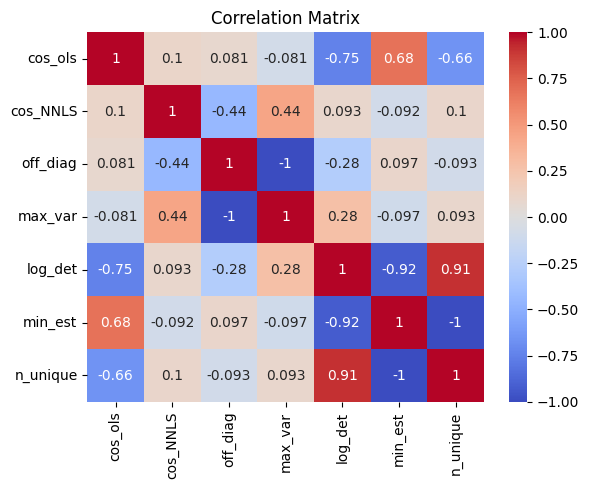

In [13]:
# Correlation heatmap
corr_matrix = A_mdtb[['cos_ols','cos_NNLS','off_diag','max_var', 'log_det', 'min_est','n_unique']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()